# Task 1: Understand the problem statement and business case

In [1]:
# The goal of this project is to build, train, test, and deploy an artificial intelligence (AI)
# model to predict sentiment from thousands of tweets. Sentiment prediction involves understanding
# of people feelings about a product or service. This kinds of analysis tools empower companies to
# automatically predict whether their customers are happy or not. The process could be done
# automatically without having humans manually review thousands of tweets/reviews.

# Natural Language Processing or NLP work by converting words(texts) into numbers. These numbers are
# then used to train an AI/ML model to make predictions. Predictions could be inferred from social media
# posts and product reviews. In this case study, we will analyze thousands of Twitter tweets to predict
# people's sentiment.

# Task 2: Import libraries and datasets

In [3]:
# Let's import all the necessary libraries for this case study
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Let's change a bit of viz styling. Setting the style of the notebook as monokai.
from jupyterthemes import jtplot
jtplot.style(theme='monokai', context='notebook', ticks=True, grid=False)

In [4]:
# The first thing i do, is to look to our data.
df = pd.read_csv('twitter.csv', encoding="utf-8")
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [7]:
# Looking above, it shows that we have 31,962 rows of data and 3 columns namely; 'id', 'label', and the
# text ('tweet'). We can also see that we can drop the 'id' column since it doesnt give much info about
# the data, the 'label' column which is what we will predict(target) later on, and the 'tweet' columns
# which we will analyze whether it is a positive(0) or negative(1) sentiment.

In [9]:
# To get more details about the data. We can use a function called df.info(), which gives us details
# about the structure of the data, and df.describe() which gives us the statistical summary of the data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [11]:
# What we can see here is the DataFrame having 3 columns: 'id', 'label', 'tweet', in which all of them
# are non-null, meaning no missing values, and their datatype, 'id' is int64, 'label' which is 0's and
# 1's is int, and 'tweet' as object, since it is a line of text. We can also see here our memory usage,
# which is helpful to track how many memory are used by our data.

In [13]:
# Let's see the statistical summary of our data.
df.describe()

,id,label
count,31962.000000,31962.000000
mean,15981.500000,0.070146
std,9226.778988,0.255397
min,1.000000,0.000000
25%,7991.250000,0.000000
50%,15981.500000,0.000000
75%,23971.750000,0.000000
max,31962.000000,1.000000


In [15]:
# Woah, we can see that we only have 2 results here, which makes sense since our last column is a text
# column and we cant get a statistical summary out of that. With the 'id' column, this mean nothing,
# since the id column is just repetition of index column but starts at 1 instead of 0. With 'label' 
# column, we get a lot of information there. For example the mean = 0.07, since our values is 0's and 
# 1's only in label column, and the mean is only 0.07, this means that we have an imbalanced data, 
# meaning, we have way more 0's than 1's, but we will check on that later on. Standard Deviation or
# std = 0.26, which is the average distance around the mean and the percentiles.

In [17]:
# Now, i think we can drop the 'id' column
df = df.drop('id', axis=1)
df

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation
...,...,...
31957,0,ate @user isz that youuu?ðððððð...
31958,0,to see nina turner on the airwaves trying to...
31959,0,listening to sad songs on a monday morning otw...
31960,1,"@user #sikh #temple vandalised in in #calgary,..."


# Task 3: Perform Exploratory Data Analysis

array([[<Axes: title={'center': 'label'}>]], dtype=object)

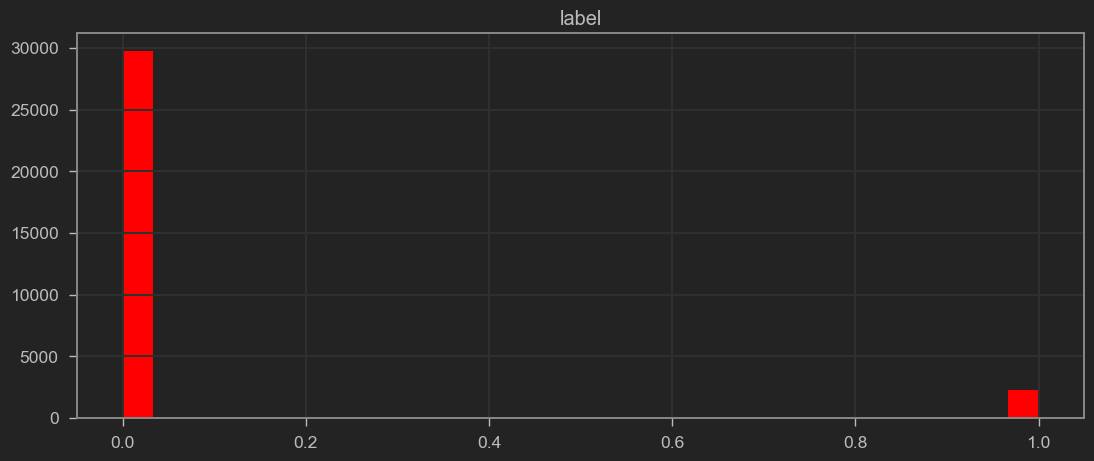

In [20]:
# Let's try to see what our data look like by plotting the histogram 
df.hist(bins = 30, figsize = (13,5), color = 'red')

In [22]:
# We can see that our 'label' column has values 0's and 1's, with 0's almost 30000 and 1's around 2500.

In [24]:
# Let's see what the exact values are.
count = df['label'].value_counts()
count

label
0    29720
1     2242
Name: count, dtype: int64

In [26]:
# To be exact, the values in our label column has 29720 of 0's and 2242 of 1's, indicating an imbalanced
# data.

<Axes: xlabel='label', ylabel='count'>

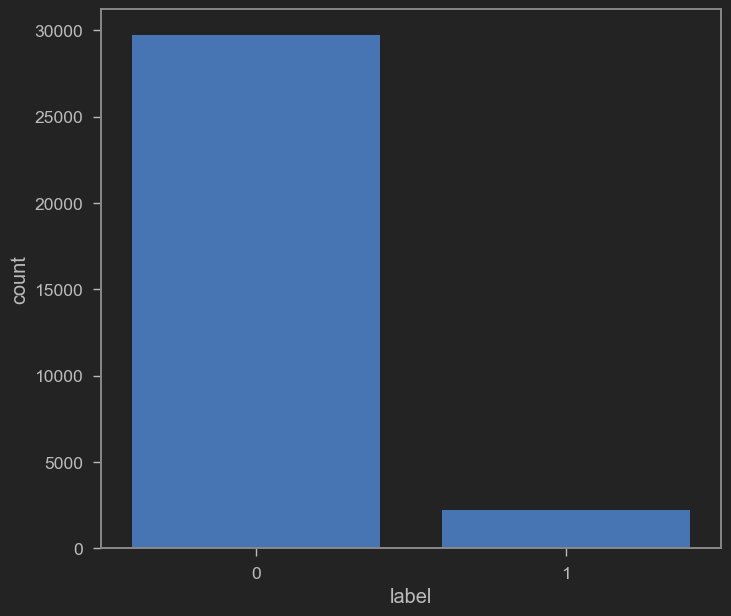

In [28]:
# We can also plot the value counts of the 'label' column using countplot from sns
sns.countplot(x = 'label', data = df)

In [30]:
# Now let's try to explore the 'tweet' column of our data. How many are the characters in 'tweet' column
df['length'] = df['tweet'].str.len()
df

,label,tweet,length
0,0,@user when a father is dysfunctional and is s...,102
1,0,@user @user thanks for #lyft credit i can't us...,122
2,0,bihday your majesty,21
3,0,#model i love u take with u all the time in ...,86
4,0,factsguide: society now #motivation,39
...,...,...,...
31957,0,ate @user isz that youuu?ðððððð...,68
31958,0,to see nina turner on the airwaves trying to...,131
31959,0,listening to sad songs on a monday morning otw...,63
31960,1,"@user #sikh #temple vandalised in in #calgary,...",67


In [32]:
# How about words per tweet?
df['word_len'] = df['tweet'].str.split().apply(len)
df

,label,tweet,length,word_len
0,0,@user when a father is dysfunctional and is s...,102,18
1,0,@user @user thanks for #lyft credit i can't us...,122,19
2,0,bihday your majesty,21,3
3,0,#model i love u take with u all the time in ...,86,14
4,0,factsguide: society now #motivation,39,4
...,...,...,...,...
31957,0,ate @user isz that youuu?ðððððð...,68,5
31958,0,to see nina turner on the airwaves trying to...,131,23
31959,0,listening to sad songs on a monday morning otw...,63,13
31960,1,"@user #sikh #temple vandalised in in #calgary,...",67,10


In [34]:
# Now, let's see the statistical summary of our updated dataframe.
df.describe()

,label,length,word_len
count,31962.000000,31962.000000,31962.00000
mean,0.070146,84.739628,13.15872
std,0.255397,29.455749,5.47815
min,0.000000,11.000000,3.00000
25%,0.000000,63.000000,9.00000
50%,0.000000,88.000000,13.00000
75%,0.000000,108.000000,17.00000
max,1.000000,274.000000,34.00000


In [36]:
# In our 'length' column, we can see that the mean length of characters per tweet is 84.7 or 85, with
# std of 29.4, the min length of characters is 11, and max is 274. Let's try to see what those tweets
# are. While in 'word_len' column there are on average 13 words per tweet, minimum is 3, max is 34.

In [38]:
# Let's view the shortest message 
df[df['length']==11]['tweet']

25195    i love you 
Name: tweet, dtype: object

In [40]:
# Let's view the longest message 
df[df['length']==274]['tweet']

19770     @user lmfao pathetic #soit   #growup #funny #...
Name: tweet, dtype: object

In [42]:
# How about the mean length which is 84 or 85
df[df['length']==84]['tweet']

43       my mom shares the same bihday as @user   bihda...
220      g o a l s ð repost from @user #propey #ocea...
640      oscar tabarez talks luis suarezâs angry reac...
723       @user another hands &amp; feet complete!! ber...
742      because great things never came from comfo zon...
                               ...                        
31445    .@user on making choices to keep herself   as ...
31448    i'm a gordo. #passpo #florence #firenze #italy...
31509    just 3 keys that are found on your computer to...
31857    traveling happy #family   holidays #car #sunny...
31883    we spent #familytime by doing simple wefie, we...
Name: tweet, Length: 333, dtype: object

<Axes: ylabel='Frequency'>

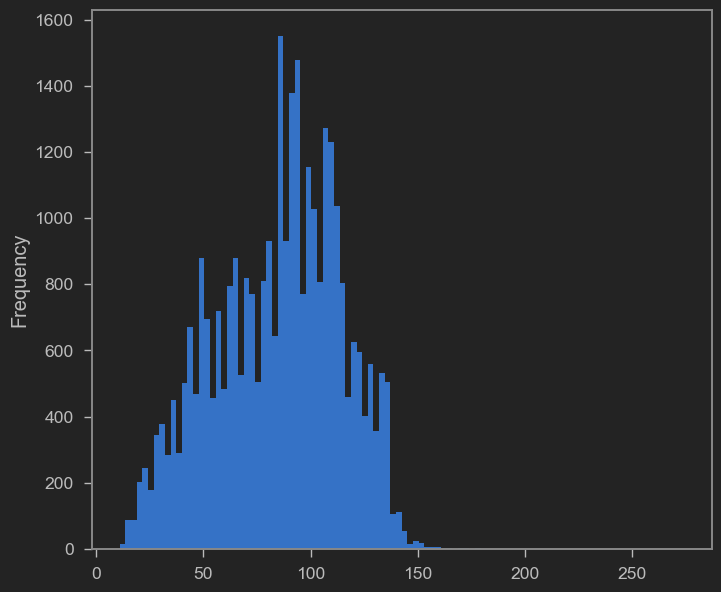

In [44]:
# Let's plot the histogram of the 'length' column
df['length'].plot(bins = 100, kind = 'hist')

In [46]:
# We are done summarizing or exploring our numerical data. I think we can now proceed and have a visual
# summary of our text data using a wordcloud. In wordcloud, the most frequent words appear to be bigger
# and bolder, while less frequent word appear to be smaller and often light in colors.

In [48]:
# Let's create a new variable positive for our positively labeled tweets and negative labeled tweets to
# see what are the positive frequent words and negative frequent words.
positive = df[df['label']==0]
positive

,label,tweet,length,word_len
0,0,@user when a father is dysfunctional and is s...,102,18
1,0,@user @user thanks for #lyft credit i can't us...,122,19
2,0,bihday your majesty,21,3
3,0,#model i love u take with u all the time in ...,86,14
4,0,factsguide: society now #motivation,39,4
...,...,...,...,...
31956,0,off fishing tomorrow @user carnt wait first ti...,61,11
31957,0,ate @user isz that youuu?ðððððð...,68,5
31958,0,to see nina turner on the airwaves trying to...,131,23
31959,0,listening to sad songs on a monday morning otw...,63,13


In [50]:
negative = df[df['label']==1]
negative

,label,tweet,length,word_len
13,1,@user #cnn calls #michigan middle school 'buil...,74,12
14,1,no comment! in #australia #opkillingbay #se...,101,9
17,1,retweet if you agree!,22,4
23,1,@user @user lumpy says i am a . prove it lumpy.,47,11
34,1,it's unbelievable that in the 21st century we'...,104,15
...,...,...,...,...
31934,1,lady banned from kentucky mall. @user #jcpenn...,59,8
31946,1,@user omfg i'm offended! i'm a mailbox and i'...,82,12
31947,1,@user @user you don't have the balls to hashta...,112,23
31948,1,"makes you ask yourself, who am i? then am i a...",87,18


In [52]:
# Now, lets combine all the tweets as one string to know what the most frequent words overall. 
sentences = df['tweet'].tolist()
len(sentences)

31962

In [54]:
# Let's not call this varaible since we combine all the 31962 characters in 1 string. Let's just keep
# it there.
sentences_as_one_string =" ".join(sentences)

In [56]:
# If you haven't yet installed wordcloud, you can do so by uncommenting the code below.
# !pip install wordcloud

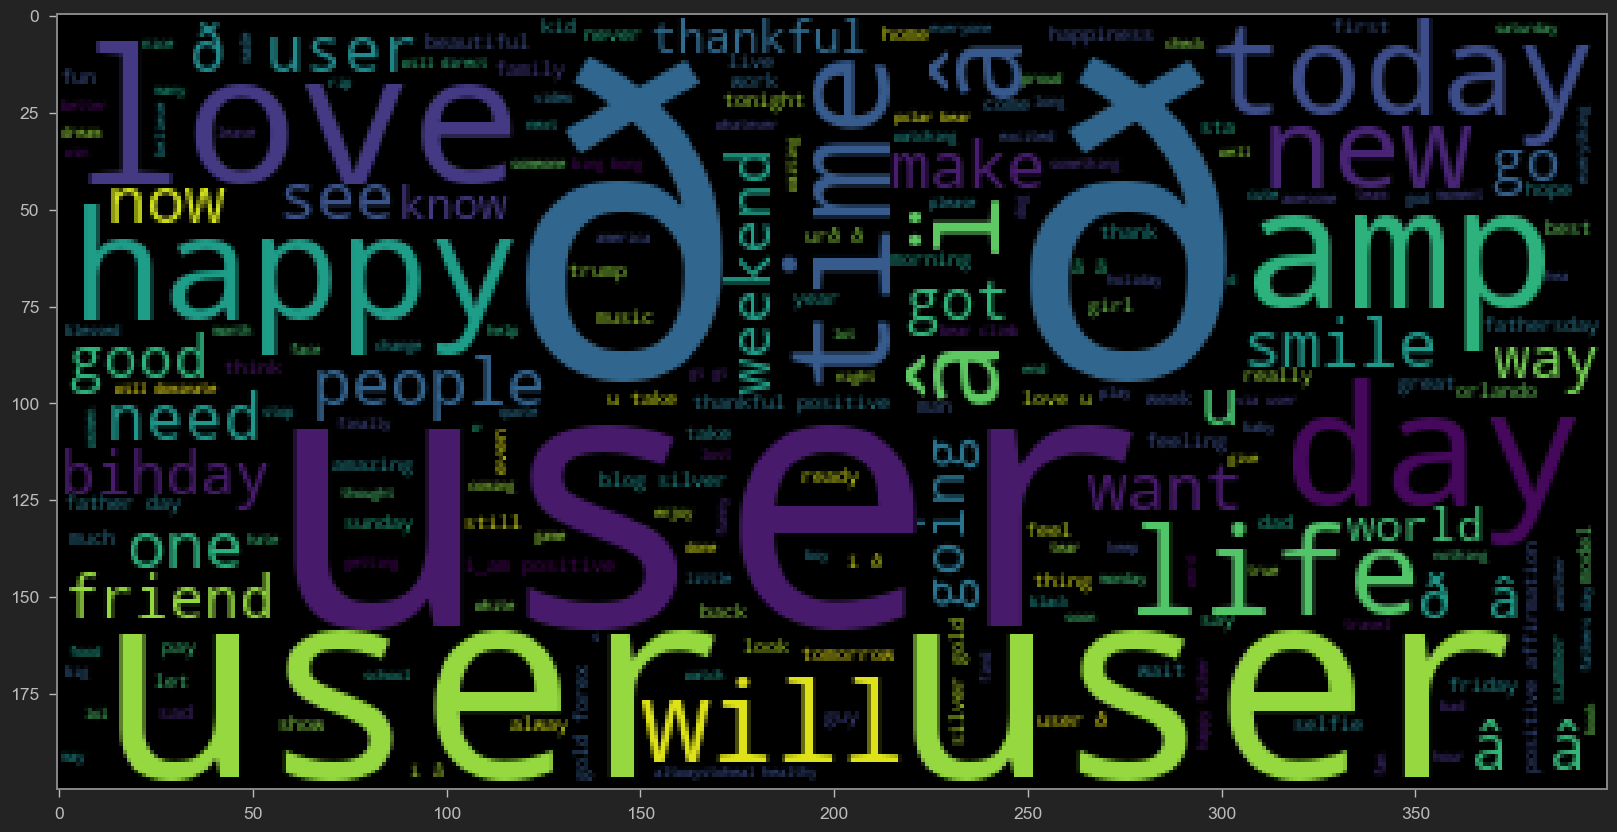

In [58]:
# Let's import WordCloud from wordcloud and plot the sentences_as_one_string to see the most frequent
# words overall.
from wordcloud import WordCloud

plt.figure(figsize=(20,20))
plt.imshow(WordCloud().generate(sentences_as_one_string))

In [59]:
# What we can see here are the words like user, time, amp, new, smile, happy, love, today, life and so
# on. Those bigger and bolder words are the most frequent in our tweets data. But what about if we try
# to plot the subsets, negative df and the positive df? Let's find out.

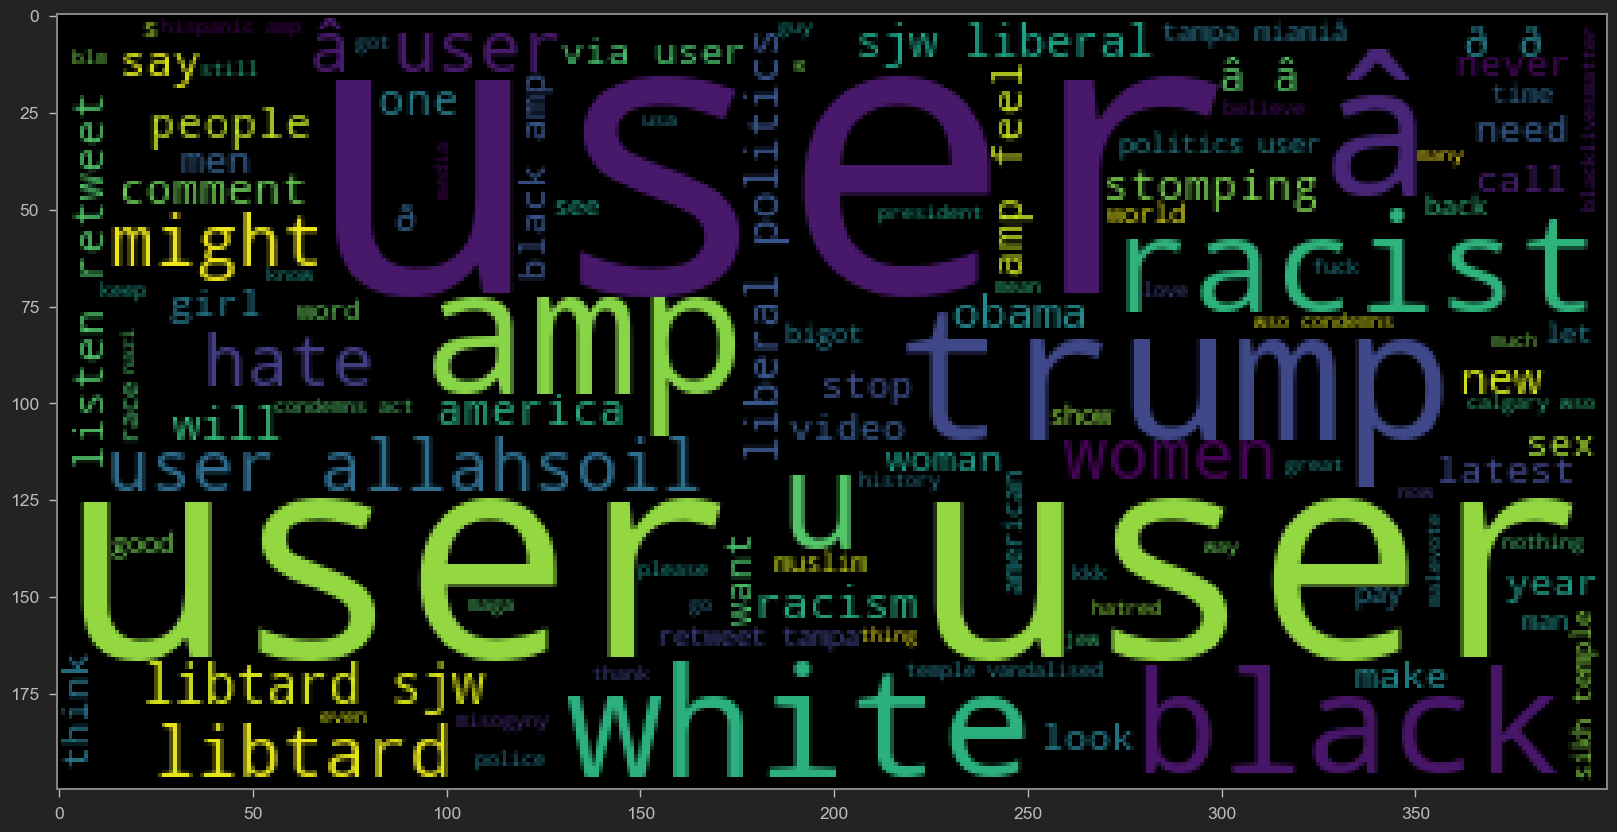

In [60]:
negative_sentences = negative['tweet'].tolist()
negative_sentences_as_one = " ".join(negative_sentences)

plt.figure(figsize=(20,20))
plt.imshow(WordCloud().generate(negative_sentences_as_one))

In [61]:
# We can see the words in negative sentences that are most frequent, like user, trump, black, white,
# racist, woman, hate, libtard, and so many more.

# Let's see what most of our positive sentences look like

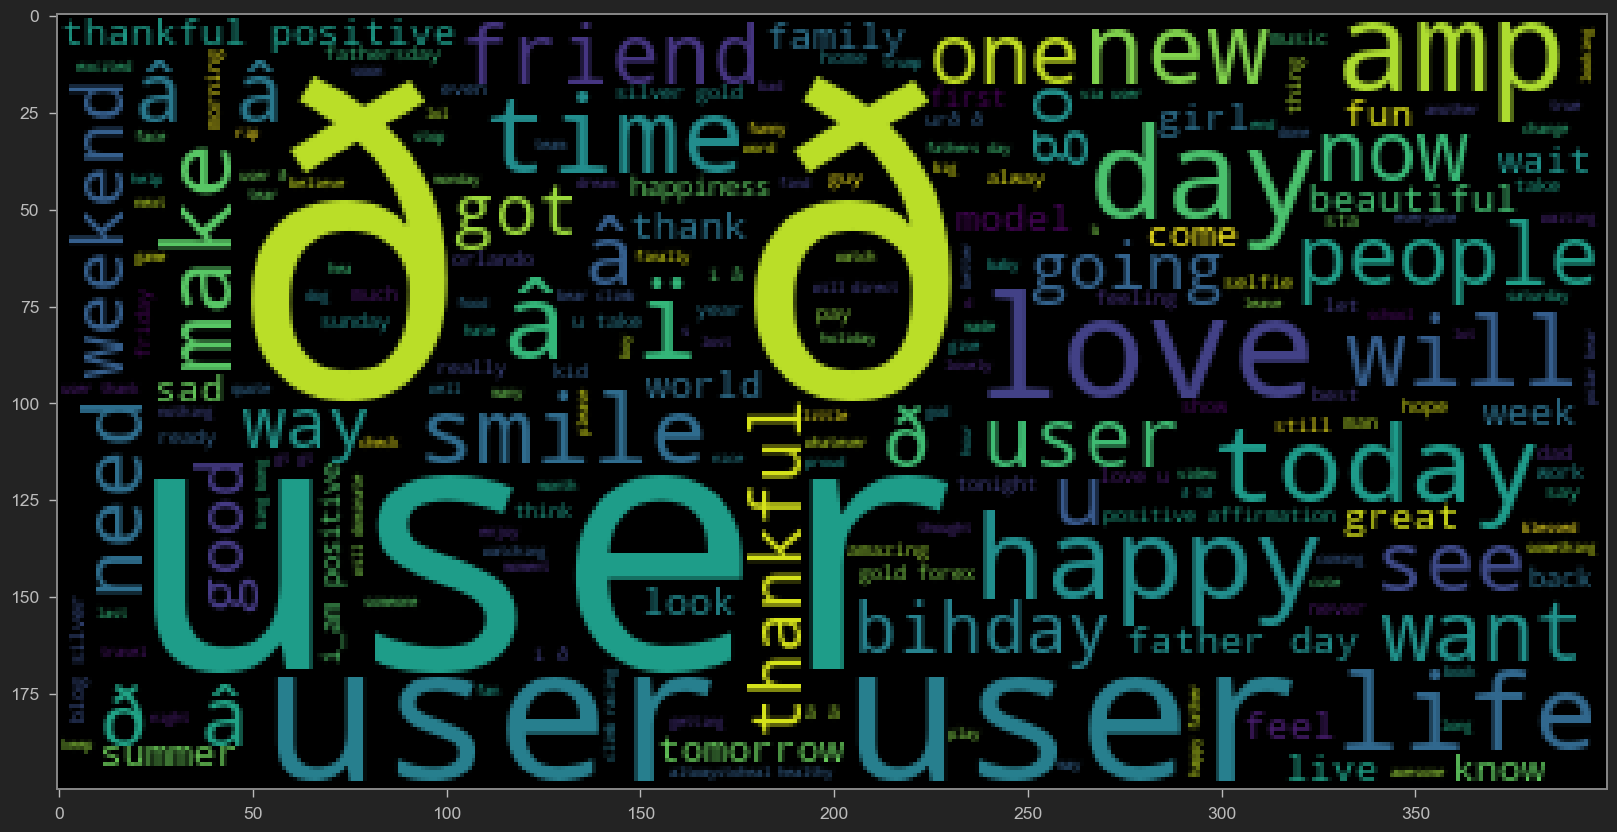

In [62]:
positive_sentences = positive['tweet'].tolist()
positive_sentences_as_one = " ".join(positive_sentences)

plt.figure(figsize=(20,20))
plt.imshow(WordCloud().generate(positive_sentences_as_one))

In [65]:
# And those are, user, love, today, day, life, happy, smile, people, new, time, thankful, and so many
# more. But i think i observed, is there are stop words, punctuations, and etc. that can be removed

# Task 4: Perform Data Cleaning

In [69]:
# Now, lets proceed to cleaning our data and start with removing the punctuations. Removing punctuations
# is usually important because it often doesn't contribute meaningful information and can create noise
# in features. We do this to remove some noise, improve consistency, helps vectorizers since 'world,'
# and 'world' are two different word for vectorizers so we need to strip the punctuations, and lastly,
# for faster processing.

In [70]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [71]:
# Let's test it first with a test variable.
Test = '$I love AI and Machine Learning!!'
Test_punc_removed = [char for char in Test if char not in string.punctuation]
Test_punc_removed_join = "".join(Test_punc_removed)
Test_punc_removed_join

'I love AI and Machine Learning'

In [77]:
# Let's test another one.
Test1 = 'Good morning beautiful people :)... I am having fun learning Machine learning and AI!!'
Test_punc_removed1 = [char for char in Test1 if char not in string.punctuation]
Test_punc_removed_join1 = "".join(Test_punc_removed1)
Test_punc_removed_join1

'Good morning beautiful people  I am having fun learning Machine learning and AI'

In [79]:
# We now know how to remove a punctuations in any text. Let's use now proceed by removing the stop words
# This involves the use of Natural Language toolkit. By importing 'nltk'
import nltk
nltk.download('stopwords') # These are the words that carry little to no meaning for the analysis like
# (the, is, at, and, a, of, will, be, to) and many more. They are so dominant to our dataset without 
# contributing much to understand the topic.

# We have to download stopwords Package to execute this command
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gianc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [80]:
# Let's try it first to this variable that i created.
Test_stopwords = 'I enjoy coding, programming and Artificial intelligence'

In [83]:
Test_stopwords.split()

['I', 'enjoy', 'coding,', 'programming', 'and', 'Artificial', 'intelligence']

In [85]:
Test_stopwords_removed = [word for word in Test_stopwords.split() if word.lower() not in stopwords.words('english')]
Test_stopwords_removed

['enjoy', 'coding,', 'programming', 'Artificial', 'intelligence']

In [87]:
# Now, lets try to combine both, removing punctuations and stopwords in an example sentence, by that we
# are confident that we can do it in our dataset.
sample = 'In this example, I will teach you how to remove stopwords and punctuations!'

sample_punc_removed = [char for char in sample if char not in string.punctuation]
sample_punc_removed_join = "".join(sample_punc_removed)
sample_cleaned = [word for word in sample_punc_removed_join.split() if word.lower() not in stopwords.words('english')]
sample_cleaned

['example', 'teach', 'remove', 'stopwords', 'punctuations']

In [89]:
# Previously, we can see in our data some weird symbols, even tho we encode it with utf-8, some
# characters aren't actually utf-8 encoded. So we will try to clean it more by removing those weird
# symbols using Regex or regular expressions. Let's define a function and apply that function to our df.
import re

def clean_text(text):
    if isinstance(text, str):
        # Remove emojis and non-ASCII
        text = re.sub(r'[^\x00-\x7F]+', ' ', text)
        return text.strip()
    return ""

df['tweet'] = df['tweet'].apply(clean_text)

In [91]:
# We observe that the row 31957 has some weird symbols, lets see if it is remove after running the
# function above.
df.iloc[31957]

# Yes, our function works.

label                               0
tweet       ate @user isz that youuu?
length                             68
word_len                            5
Name: 31957, dtype: object

In [93]:
# Now lets define a pipeline to clean up all the messages in our dataset
# The pipeline performs the following: (1) remove punctuation, (2) remove stopwords

def message_cleaning(message):
    Punc_removed =  [char for char in message if char not in string.punctuation]
    Punc_removed_join = "".join(Punc_removed)
    cleaned = [word for word in Punc_removed_join.split() if word.lower() not in stopwords.words('english')]
    return cleaned

# Task 5: Visualize Cleaned Datasets

In [96]:
# Let's test the newly created function in our original dataset
df_clean = df['tweet'].apply(message_cleaning)
df_clean

0        [user, father, dysfunctional, selfish, drags, ...
1        [user, user, thanks, lyft, credit, cant, use, ...
2                                        [bihday, majesty]
3                      [model, love, u, take, u, time, ur]
4                        [factsguide, society, motivation]
                               ...                        
31957                              [ate, user, isz, youuu]
31958    [see, nina, turner, airwaves, trying, wrap, ma...
31959    [listening, sad, songs, monday, morning, otw, ...
31960    [user, sikh, temple, vandalised, calgary, wso,...
31961                                [thank, user, follow]
Name: tweet, Length: 31962, dtype: object

In [97]:
# Let's compare the same tweet before cleaning and after cleaning.

print(df_clean[5]) # show the cleaned up version

['22', 'huge', 'fan', 'fare', 'big', 'talking', 'leave', 'chaos', 'pay', 'disputes', 'get', 'allshowandnogo']


In [98]:
print(df['tweet'][5]) # show the original version

[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo


In [99]:
# Good! Our data now is cleaned and ready for training.

# Task 6: Prepare the data by applying count vectorizer

In [101]:
# Now that our data is clean, we can apply now the count vectorizer to convert our collection of text
# documents into a bag-of-words numerical representation. This happens by, first, splitting each
# document into tokens, then creates a dictionary of all unique tokens with tokens as keys, and counts
# as values. For each document, it counts how many times each vocabulary word appears. And returns a
# sparse matrix, where rows = documents, columns = vocabulary words, values = counts.

from sklearn.feature_extraction.text import CountVectorizer
# Define the cleaning pipeline we defined earlier
vect = CountVectorizer(analyzer = message_cleaning, dtype = np.uint8)
tweets_countvect = vect.fit_transform(df['tweet'])

In [102]:
# Let's see the shape of our converted text data 
tweets_countvect.shape

(31962, 41202)

In [ ]:
# As you can see we have 41202 columns, meaning thats our unique words in our data, which became our
# features. We can get our features by calling the get_feature_names_out().

In [117]:
# Let's see all the feature names in our converted data. 
print(vect.get_feature_names_out())

['0' '0000001' '00027' ... 'zzz' 'zzzzzzs' 'zzzzzzzz']


In [127]:
# Let's loop through it to observe all of the feature names
for word in vect.get_feature_names_out():
    print(word)

0
0000001
00027
001
0035
00h30
01
0115
0161
019
01926889917
01b
02
0265
0266808099
02900
03
030916
03111880779
032
033
0345
039
04
045
04k
05
0506823156
06
06052016
0606
060616
0608
0608wed
0609
0610
061116
0612
0613
0616
0617
0618
0618saturday7monthscouple
0620
06202016
0622
0624
07
07000
07040
07044
07150
07190
07400
07468
07500
076
07788427999
07800
07840
07850
07870
07900
07930
07950
07b
08
0806
080616
088b
09
09062016
0933m
09600
0k
0shares
0tolerancemovie
1
10
100
1000
100000
10003
10007
1000gifts
1000th
1000x
1000yr
1001
1001000s
10014
10021
10025
10040
100616
10064
100d
100daysofcode
100daysofpigpaintings
100daysoftea
100faces
100happydays
100happysongs
100juice
100k
100ml
100pm
100yr
101
10125
1014
10143hr
1015
1017
1019
101dalmatians
101daysofsmiles
1027
102816
102pm
1030
10353
104
1044
10450
10480
10550
1059am
105kg
106
10650
10670
1070
10700
1080
10830
1096
10a
10alltypespos
10am
10days
10hrs
10k
10kday
10kms
10m
10meses
10miler
10millionmiler
10minmile
10minutes
10minutest

In [121]:
# Now, lets convert the count vectorizer of tweets data to array and make it our new dataframe
print(tweets_countvect.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [123]:
X = pd.DataFrame(tweets_countvect.toarray())
X

,0,1,2,3,4,5,6,7,8,9,...,41192,41193,41194,41195,41196,41197,41198,41199,41200,41201
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31957,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31958,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31960,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [125]:
# Then, set 'label' as y variable or the target variable
y = df['label']
y

0        0
1        0
2        0
3        0
4        0
        ..
31957    0
31958    0
31959    0
31960    1
31961    0
Name: label, Length: 31962, dtype: int64

In [129]:
# Now, our data is ready for modelling.

# Task 7: Understand the theory and intuition behind Naive Bayes Classifiers

# Task 8: Train a Naive Bayes Classifier

In [135]:
# Checking the shape of X.
X.shape

(31962, 41202)

In [137]:
# Checking the shape of y.
y.shape

(31962,)

In [139]:
# Now, let's split our data to train and test sets. Splitting our data into train-test is importan
# because it helps us check if our model actually learned something useful or it just memorized the data

# When we train a machine learning model, we give it a set of examples (the training set) so it can
# learn patterns. But if we only judge the model's performance using the same data it learned from, we
# might be fooled - it could just be 'parroting' the answers it already saw. That is called overfitting

# To avoid that we need to split our data to train-test, usually 80 and 20, but 75 and 25 are also
# common. But in this study, we will train the model to the 80% of our data, and test it to the
# remaining 20%.

# The test set is the data the model has never seen before. We use it to check how well
# the model can handle new, unseen examples  
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [141]:
# Now, lets import the Multinomial Naive Bayes model from scikitlearn
# MultinomialNB is often used for text classification tasks, especially when the features are word
# counts or term frequencies

from sklearn.naive_bayes import MultinomialNB

# Now, let's create an instance of the Naive Bayes classifier. Train the classifier using the training
# data both of X and y. X_train contains the features(word_counts) and y_train contains the 
# corresponding labels.
clfNB = MultinomialNB()
clfNB.fit(X_train, y_train)

MultinomialNB()

# Task 9: Assess trained model performance

In [143]:
# Let's import the tools for evaluating our model, those are:
# classification_report which gives precision, recall, f1-score, and support for each class
# confusion_matrix which shows how many predictions were correct/incorrect for each class
from sklearn.metrics import classification_report, confusion_matrix

<Axes: >

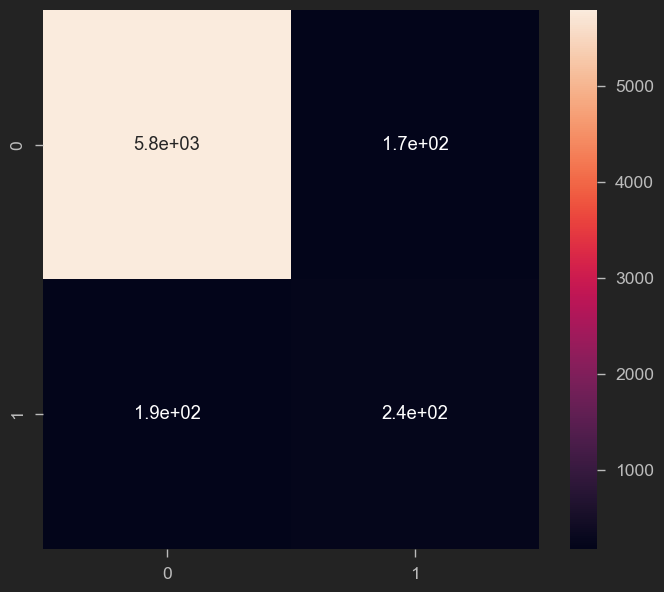

In [145]:
# Now, let's use the trained Naive Bayes model to predict labels for the test set
y_predict_test = clfNB.predict(X_test)
# Let's create a confusion matrix comparing the true labels (y_test) and the predicted labels (y_predict_test)
cm = confusion_matrix(y_test, y_predict_test)
# Let's visualize the confusion matrix as a heatmap for easier interpretation
sns.heatmap(cm, annot=True)

In [149]:
# Let's print a detailed classification report (precision, recall, F1-score, support)
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5970
           1       0.58      0.56      0.57       423

    accuracy                           0.94      6393
   macro avg       0.77      0.77      0.77      6393
weighted avg       0.94      0.94      0.94      6393



In [ ]:
# The results supports what we have observed in our dataset. In our data exploration and data cleaning
# process, we observed that our data is imbalanced, meaning there are more 0's than 1's, that is why our
# mean for label is only 0.07.

# Now, our result shows that our model is excellent at predicting class 0, and only moderate at detecting
# class 1, often misclassifying it as class 0. The high accuracy which is 0.94 is mainly due to the large number of
# class 0 samples being predicted correctly. However, since the dataset is imbalanced, meaning class 0 has far more
# samples than class 1, accuracy alone can be misleading.

# While the current model is effective in identifying positive sentiments, it requires further tuning to ensure
# reliable detection of negative points. Since our goal for this study is to predict whether a sentiment is positive or
# negative, therefore, we need to achieve a high score on correctly predicting both positive and negative sentiments.

# RECOMMENDATION: To achieve a balanced performance across both positive and negative sentiments, these are what we
# needed to improve: (1) Data Balancing - Apply resampling methods such as SMOTE (Synthetic Minority Oversampling
# Technique) or Random Undersampling to improve class distribution. (2) Class Weight = 'balanced' – Assign higher
# weights to the minority class during training to penalize its misclassification more heavily. (3) Threshold
# Tuning – Adjust the classification threshold to improve recall for negative sentiment without overly compromising
# precision. (4) Data Expansion – Collect additional negative sentiment tweets to naturally balance the dataset
# and improve the model’s generalization.